In [2]:
from cProfile import label
from turtledemo.chaos import line

from fontTools.diff import color

from Notebooks.Geracao_matriz_alinhamento import melhor_caminho
from pyparsing import alphas
!pip install -qU pandas dtaidistance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import numpy as np
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

In [4]:
test_df = pd.read_csv('../Dataset/UCRArchive_2018/UMD/UMD_TEST.tsv', sep='\t')
train_df = pd.read_csv('../Dataset/UCRArchive_2018/UMD/UMD_TRAIN.tsv', sep='\t')

In [5]:
test_df

,1,0.017644459,0.030949268,0.05055511,0.044484418,0.053276844,0.0415762,0.030947384,0.027085506,0.013763773,...,0.024574725,0.033780034,0.026588896,0.013932152,0.024928126,0.022589026,0.038248,0.049837783,0.053419439,0.040420371
0,1,0.041296,0.003551,0.027470,0.013158,0.009571,0.008074,0.043743,0.040592,0.012190,...,0.060539,0.046991,0.023586,0.001562,-0.002196,0.036730,0.039027,0.007754,0.004697,0.031440
1,1,-0.000720,0.013283,0.029450,0.045201,0.006317,0.018805,0.028901,0.013832,0.015240,...,0.016442,0.039508,0.015171,0.034708,0.010835,0.002942,0.006924,0.029502,0.040786,0.023144
2,1,0.005201,0.013363,0.025733,0.026653,0.038946,0.012494,0.028303,0.032011,0.009467,...,0.006383,0.037448,0.044335,0.011143,-0.003624,0.001467,0.020991,0.027675,0.001621,0.015858
3,1,0.022926,0.027036,0.011668,0.019500,0.036049,-0.001297,0.019717,0.039583,0.020628,...,0.026997,0.036653,0.018117,0.018314,0.012536,0.040599,0.016590,0.032730,0.002498,0.011260
4,1,0.004897,0.016985,0.003485,0.006491,0.028674,0.005622,0.006906,0.011857,0.022167,...,0.041374,0.030726,0.042439,0.013007,0.034942,0.026134,0.037174,0.025711,0.034479,0.028682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,3,0.008298,0.017240,0.010756,0.049488,0.005331,0.036829,0.045530,0.046181,0.044288,...,0.015062,0.028319,0.028443,0.051677,0.036134,0.038030,0.047388,0.006875,0.052691,0.051594
139,3,0.004801,0.042964,0.034519,-0.003426,-0.003353,0.005231,0.002309,0.029905,0.011177,...,0.017705,0.045264,0.041434,0.040670,0.034613,0.001551,0.017716,0.001042,0.047787,0.020318
140,3,0.033658,0.038235,0.009848,0.016061,0.026287,0.029979,0.024099,0.023647,0.017566,...,0.019306,0.022595,0.014942,0.009259,0.019186,0.035905,0.031095,0.006592,0.017948,-0.003614
141,3,0.022805,0.020270,0.015546,0.038309,0.016303,0.011456,0.018286,0.015730,0.007319,...,0.013016,0.030138,0.025736,0.005955,0.050157,0.014435,0.005638,0.036126,0.010751,-0.005682


In [6]:
train_df

,1,0.053053325,0.040692819,0.039424033,0.006438627,0.01815379,0.043179367,0.015575777,0.023580542,0.0068416659,...,0.035886841,0.047126149,0.033465737,0.035244965,0.027786101,0.045970288,0.027780141,0.044234926,0.022630805,0.043698975
0,1,0.043683,0.044506,0.044794,0.048495,0.020071,0.055454,0.051247,0.053958,0.043487,...,0.022566,0.028620,0.042745,0.008034,0.011900,0.034195,0.046746,0.029555,0.028873,0.004255
1,1,0.022591,0.041485,0.036357,0.041029,0.043406,0.021945,0.006065,0.041733,0.027640,...,0.022767,0.039593,0.036259,0.034306,0.007357,0.016879,0.010141,0.007914,0.045287,0.013247
2,1,0.002490,0.007718,0.029483,0.045494,0.045347,0.005060,0.047209,0.018302,0.043318,...,0.040746,0.000729,0.044491,0.015115,0.045216,0.020997,0.024981,0.020005,0.036766,0.031707
3,1,0.030316,0.003985,0.044046,0.037493,0.006531,0.033350,0.020327,0.035554,0.044127,...,0.052542,0.044902,0.010675,0.015468,0.008975,0.044703,0.019259,0.029804,0.015642,0.028941
4,1,0.010965,0.016505,0.033659,0.012063,0.018570,0.033006,0.038811,-0.002631,0.027331,...,0.014874,0.009690,0.036981,0.033662,0.040107,0.031932,0.029045,0.020583,0.013930,0.041738
5,1,0.044371,0.052699,0.012101,0.025012,0.009519,0.054856,0.029893,0.019053,0.041729,...,0.038385,0.013298,0.014435,0.018449,0.055584,0.006752,0.020973,0.024906,0.013524,0.028008
6,1,0.033693,0.004775,0.026586,0.022547,0.043450,0.015039,0.018163,0.020877,0.016738,...,0.021751,0.045638,0.003594,0.026433,0.010020,0.045836,0.040150,0.049890,0.018224,0.031065
7,1,-0.000551,0.034474,0.007377,0.009250,0.001402,0.021975,0.036177,0.018459,0.043253,...,0.028976,0.029915,0.036100,0.035385,0.016580,0.007649,0.043109,0.005565,0.023522,0.012942
8,1,0.009621,0.033562,0.011098,0.014061,0.037549,0.045264,0.016221,0.033417,0.016521,...,0.028313,0.021456,0.042516,0.047117,0.014056,0.010920,0.030293,0.055598,0.014061,0.007290
9,1,0.010965,0.016505,0.033659,0.012063,0.018570,0.033006,0.038811,-0.002631,0.027331,...,0.014874,0.009690,0.036981,0.033662,0.040107,0.031932,0.029045,0.020583,0.013930,0.041738


In [7]:
dados_teste = test_df.iloc[0, 1:].values
dados_treino = train_df.iloc[0, 1:].values

In [8]:
dados_teste

array([ 4.1296098e-02,  3.5509429e-03,  2.7470177e-02,  1.3158136e-02,
        9.5709645e-03,  8.0744454e-03,  4.3742981e-02,  4.0592289e-02,
        1.2189977e-02,  3.2360197e-02,  4.2360442e-02,  4.0469020e-02,
        1.8908861e-02,  5.1414820e-02,  4.4906022e-02,  4.7830919e-03,
        9.0072947e-03,  1.3814912e-02,  1.1800000e-01,  4.1900000e-01,
        7.2000000e-01,  8.8600000e-01,  9.6600000e-01,  1.0030000e+00,
        1.0170000e+00,  1.0220000e+00,  1.0230000e+00,  9.0700000e-01,
        6.0200000e-01,  3.0000000e-01,  1.3200000e-01,  5.4000000e-02,
        4.4924218e-02,  4.4513516e-02,  5.0668041e-02,  1.5392738e-02,
        9.4030613e-03,  2.4746926e-03,  7.9961871e-03,  1.1149902e-02,
        3.0135737e-02,  7.8494058e-05,  3.1198629e-02,  2.6822850e-02,
        1.3586545e-02,  5.5311745e-02,  5.6883396e-02, -1.4300000e-01,
       -5.4900000e-01, -9.5500000e-01, -1.1820000e+00, -1.2860000e+00,
       -1.3280000e+00, -1.3460000e+00, -1.3530000e+00, -1.3560000e+00,
      

In [9]:
dados_treino

array([ 0.04368289,  0.04450579,  0.04479432,  0.04849515,  0.02007078,
        0.05545352,  0.05124677,  0.05395753,  0.04348738,  0.00497237,
        0.0285193 ,  0.00782864,  0.00447721,  0.01842173,  0.04167938,
        0.03160591,  0.02832558,  0.00796597,  0.118     ,  0.419     ,
        0.72      ,  0.886     ,  0.966     ,  1.003     ,  1.017     ,
        1.022     ,  1.023     ,  0.907     ,  0.602     ,  0.3       ,
        0.132     ,  0.054     ,  0.05537955,  0.05633059,  0.02708835,
        0.01941216,  0.0023697 ,  0.04583824,  0.00879532,  0.04287179,
       -0.00185798,  0.04219211,  0.04374358,  0.01233356,  0.04590405,
        0.05174007,  0.02982113, -0.143     , -0.549     , -0.955     ,
       -1.182     , -1.286     , -1.328     , -1.346     , -1.353     ,
       -1.356     , -1.36      , -1.363     , -1.362     , -1.359     ,
       -1.36      , -1.364     , -1.367     , -1.366     , -1.367     ,
       -1.368     , -1.366     , -1.364     , -1.364     , -1.36

In [10]:
s1 = dados_treino
s2 = dados_teste

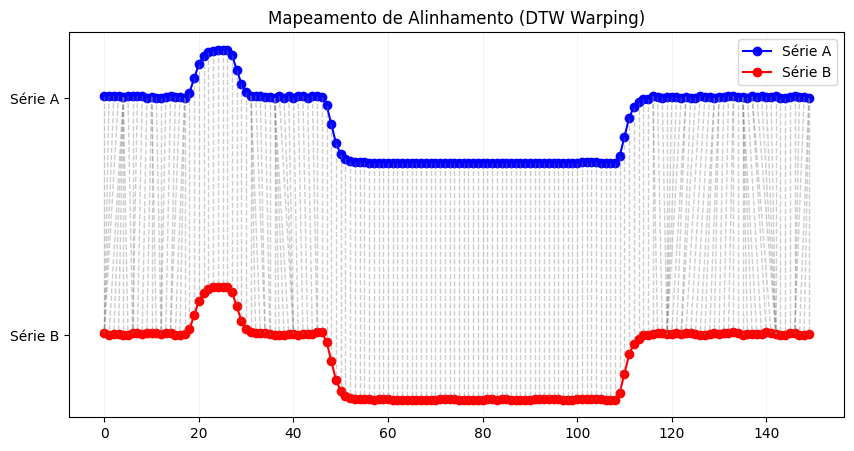

In [15]:
# Calculando o melhor caminho
melhor_caminho = dtw.warping_path(s1, s2)

# Criando a visualização
plt.figure(figsize=(10,5))

# Plotando a série 1 no topo e a série 2 abaixo (com um offset vertical)
offset = 5
plt.plot(s1 + offset, label="Série A", color="blue", marker="o")
plt.plot(s2, label="Série B", color="red", marker="o")

# Desenhando as linhas de mapeamento (conexões)
# O caminho contém tuplas (índice_s1, índice_s2)
for (idx1, idx2) in melhor_caminho:
    # Desenha uma linha entre s1[idx1] e s2[idx2]
    # Coordenadas: [x1, x2], [y1, y2]
    plt.plot([idx1, idx2], [s1[idx1] + offset, s2[idx2]], color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.title("Mapeamento de Alinhamento (DTW Warping)")
plt.yticks([0, offset], ["Série B", "Série A"])
plt.legend()
plt.grid(axis='x', alpha=0.2)
plt.show()